In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Imports

In [22]:
import os
import sys

notebook_dir = os.path.dirname(os.path.abspath('__file__'))

project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from src.utils.preprocessors import read_all_files,index_df,preprocess_context_data,normalize_tick
from src.utils.transformers import *
from src.utils.plotters import *
from src.utils.constants import *

# File Preparation

In [24]:
dfs_in_use = ["matches","rounds","player_frames"]
dfs = read_all_files(dfs_in_use,path="../src/esta/parsed/")
dfs = index_df(dfs,include=dfs_in_use[1:],index_by=["match_id","round_num"])
dfs = preprocess_context_data(dfs)
dfs = normalize_tick(dfs,include=dfs_in_use[1:])

Indexed DataFrame 'rounds' by ['match_id', 'round_num'].
Indexed DataFrame 'player_frames' by ['match_id', 'round_num'].


In [25]:
with open("../.awpy/maps/map-data.json", "r") as f:
    all_map_data = json.load(f)

In [26]:
matches_df = dfs["matches"]

In [27]:
selected_map = 'de_mirage'
map_data = all_map_data[selected_map]
selected_matches = matches_df[matches_df.map_name == selected_map]
display(selected_matches.head())
selected_match = selected_matches.iloc[0]
selected_round = 5
sel_idx = (selected_match.match_id,selected_round)

,client_name,map_name,tick_rate,playback_ticks,playback_frames_count,parsed_to_frame_idx,match_id,demo_id,competition_name,hltv_url,match_date,match_name
0,GOTV Demo,de_mirage,127,343251,342767,342784,0839a031-0e2c-4c03-b4bc-b5ba05fe669a,01746483-b3bd-4e4b-a2f2-0de97b17600d,PGL Major Antwerp 2022,https://www.hltv.org/matches/2356160/heroic-vs...,1652781600000,heroic-vs-vitality-pgl-major-antwerp-2022
0,GOTV Demo,de_mirage,127,471790,471564,471581,0a075b4d-576e-46f2-b944-fe9542faee54,04f0fb8f-a4d7-497c-857e-316300fadee3,IEM Katowice 2022,https://www.hltv.org/matches/2354381/furia-vs-...,1645124400000,furia-vs-astralis-iem-katowice-2022
0,GOTV Demo,de_mirage,127,426251,425998,426016,a98ffca7-e968-4a54-9e8f-22f101c2502b,022866a3-090e-42eb-ab8e-aa553a575ada,IEM Katowice 2021,https://www.hltv.org/matches/2346573/faze-vs-f...,1613905200000,faze-vs-furia-iem-katowice-2021
0,GOTV Demo,de_mirage,127,441259,440692,440707,a56115fd-a0ba-4eea-a618-91fd6c57177c,015f7c8d-2bc0-4d83-88e7-60648d2b221c,BLAST Premier Fall Showdown 2021,https://www.hltv.org/matches/2351973/heroic-vs...,1634034600000,heroic-vs-poggerz-blast-premier-fall-showdown-...
0,GOTV Demo,de_mirage,127,493224,492014,492029,f218743d-5e8b-436e-91bd-b7b3664c56c3,0418eb19-853e-4b56-955c-d3eedf2b7e12,BLAST Premier Spring Final 2021,https://www.hltv.org/matches/2349173/natus-vin...,1623853200000,natus-vincere-vs-faze-blast-premier-spring-fin...


# Viz

In [28]:
from src.utils.plotters import plot_loc_img_unicode

/tmp/nix-shell.e4YfR1/ipykernel_11463/2358143303.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  dfs["player_frames"].loc[sel_idx])


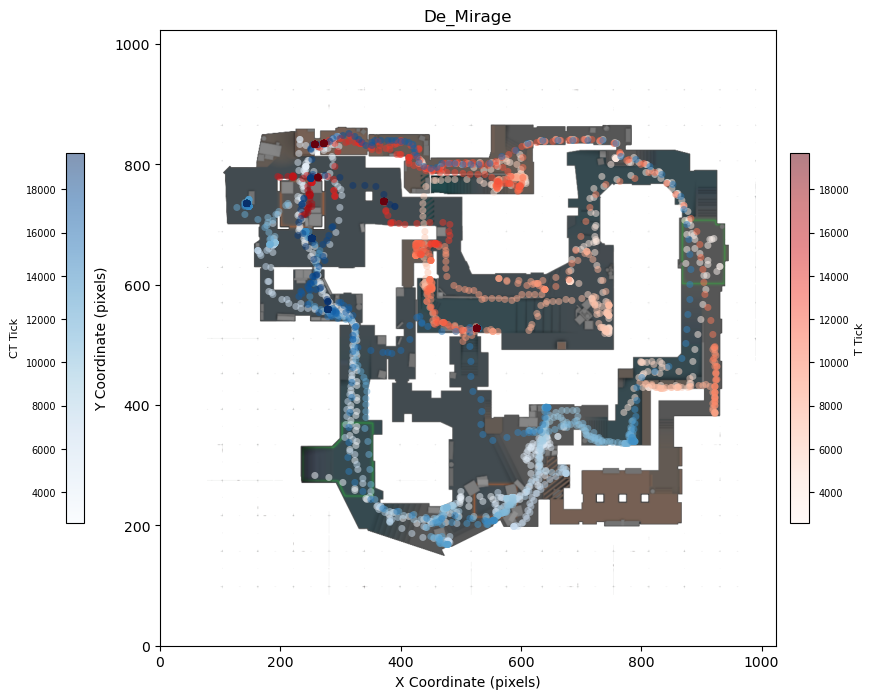

In [29]:
transformed_loc = transform_coord(map_data,
                                  dfs["player_frames"].loc[sel_idx])

img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")

loc_fig, loc_ax = plot_loc_img_unicode(transformed_loc, 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

# PCA

In [41]:
from src.utils.pca import *

In [42]:
tf_loc = transformed_loc[["tick","side","steam_id","x","y"]]

In [43]:
sampling_rate = 10
all_ticks = sorted(tf_loc['tick'].unique())
all_ticks = np.array(all_ticks[::sampling_rate])

In [44]:
norm = plt.Normalize(vmin=all_ticks.min(), vmax=all_ticks.max())

In [45]:
side_df = pd.DataFrame()
side = "CT"
raw_loc_df = tf_loc[tf_loc.side == side].reset_index().drop(["match_id","round_num"],axis=1)
player_encode = {k:f"{p}" for p,k in enumerate(sorted(raw_loc_df.steam_id.unique()),start=1)}

index = []
for i in range(1,len(raw_loc_df.steam_id.unique())+1):
    index.append(f"p{i}x")
    index.append(f"p{i}y")
for tick in all_ticks:
    p_coords= list(raw_loc_df[raw_loc_df.tick == tick].sort_values("steam_id")[["x","y"]].values.reshape(1,-1)[0])
    side_df.loc[tick,index] = p_coords

side_df.index.set_names(["tick"],inplace=True)
print(side_df.shape)
display(side_df.head())

(27, 10)


,p1x,p1y,p2x,p2y,p3x,p3y,p4x,p4y,p5x,p5y
tick,,,,,,,,,,
2594,315.411591,327.957642,324.543274,310.074585,326.456848,341.275879,257.403259,284.338928,324.306793,263.07251
3234,295.258484,564.082764,311.320648,552.794434,282.587067,572.540161,481.625549,221.676819,532.005127,249.393921
3874,241.059494,789.877625,238.636932,767.418884,242.450195,798.824585,557.834473,238.60376,629.839966,300.119629
4514,285.200623,814.616394,279.189484,828.983887,257.357239,665.060181,605.444397,316.325806,671.282227,364.847168
5154,295.461487,765.940796,229.322067,749.337402,319.29483,443.68512,623.06604,325.595642,638.28241,336.293884


In [46]:
temporal_pca_results = temporal_pca(side_df,10,5,scale_factor=128)
test_result = temporal_pca_results["window_1"]

In [47]:
test_result

{'start': 2594,
 'end': 8354,
 'pca': PCA(n_components=5),
 'scaler': StandardScaler(),
 'pca_result':         PC1       PC2       PC3       PC4       PC5
 0 -2.953446 -3.280339  1.983336 -0.588896 -0.053137
 1 -0.188203 -2.393406 -0.515234  0.676502  0.510225
 2  2.683861 -1.489436 -0.819490 -0.013722  0.832537
 3  3.395521 -0.228906  1.083796  0.301229 -0.363160
 4  2.122301  0.555539  0.712041 -0.532766 -0.653763
 5 -0.344574  0.191556 -1.329527 -0.997790 -0.494084
 6 -1.596739 -0.446219 -1.504159  1.359795 -0.771908
 7 -1.073829  1.604554 -1.222942 -0.817094  0.159441
 8 -1.152887  2.194196 -0.129776 -0.112359  0.622889
 9 -0.892004  3.292461  1.741954  0.725100  0.210958,
 'components':            p1x       p1y       p2x       p2y       p3x       p3y       p4x  \
 PC24  0.403879 -0.134787  0.075044  0.184472  0.289311 -0.064237  0.247960   
 PC1  -0.240498  0.438378 -0.025023  0.432804 -0.327779  0.396526  0.193983   
 
            p4y       p5x       p5y  
 PC24 -0.114451  0.2939

PC24
PC24
PC24
PC24
PC1


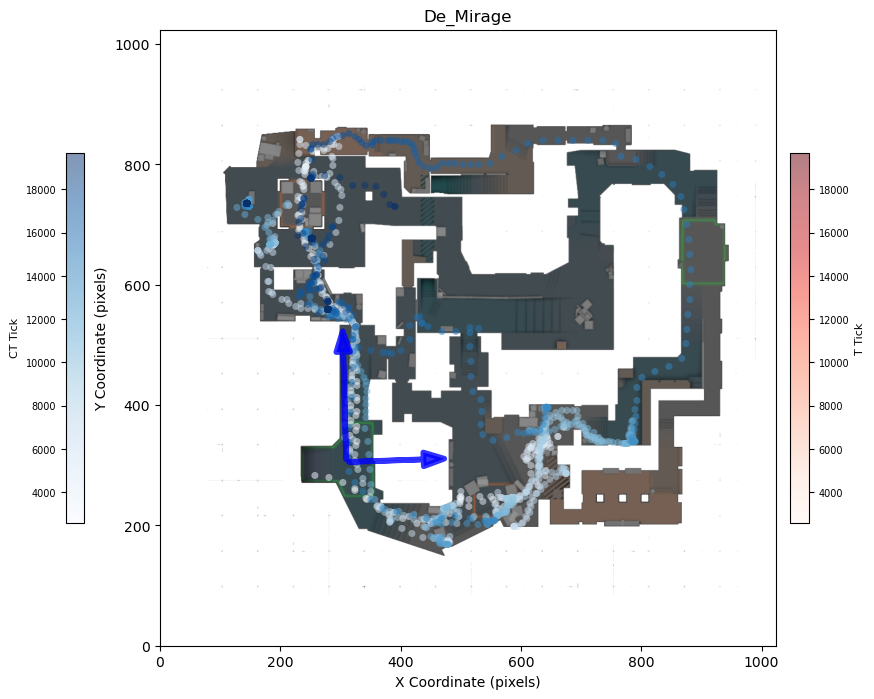

In [48]:
from matplotlib.patches import FancyArrowPatch

vectors = test_result["pc_vectors"].values()
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")
loc_fig, loc_ax = plot_loc_img_unicode(tf_loc[tf_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

for vector in vectors:
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color="blue",
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

for player,pc in inverse_pc_groups(test_result["pc_groups"]).items():
    print(pc)
    p_coord_cols = [player+"x",player+"y"]
    psx,psy = side_df.loc[test_result["start"],p_coord_cols]
    pdx,pdy = test_result["components"].loc[pc,p_coord_cols] 
    # img_loc_ax = plt.quiver(psx,psy,pdx,pdy,zorder=20)


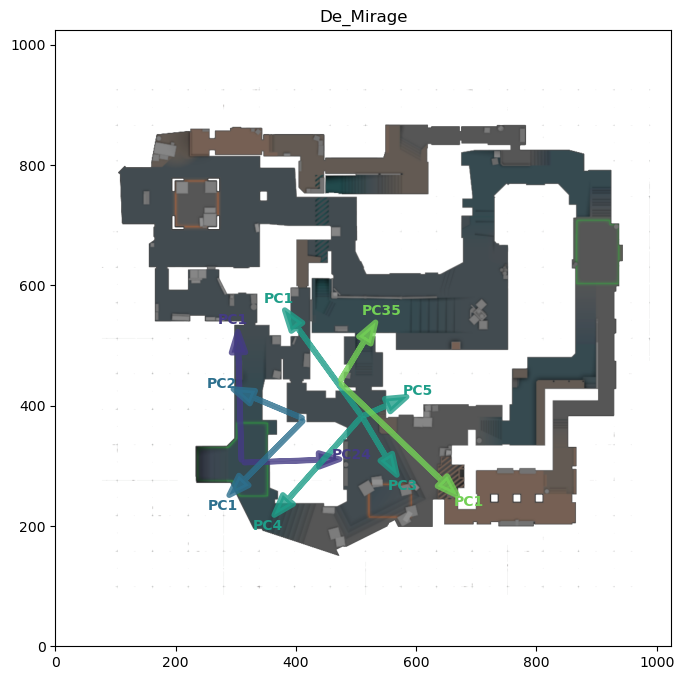

In [49]:
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")
for window in temporal_pca_results.values():
    for pc,vector in window["pc_vectors"].items():
        color = plt.get_cmap("viridis")(norm(vector["tick"]))
        arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color=color,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
        img_loc_ax.add_patch(arrow)

        
        vec_dx = vector["end_pos"][0] -vector["start_pos"][0]
        vec_dy = vector["end_pos"][1] -vector["start_pos"][1]
        
        # Small offset factor from the end of the arrow
        text_offset_factor = 15 
        
        # Adjust offset based on direction of the vector
        # This tries to place text slightly to the "outside" or "ahead" of the arrow
        text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1)
        text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1)
    
        # If the vector is mostly horizontal, adjust y-offset more. If vertical, adjust x-offset more.
        if abs(vec_dx) > abs(vec_dy): # More horizontal
            text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1) * 0.5 # Less y-offset
        else: # More vertical
            text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1) * 0.5 # Less x-offset
    
    
        img_loc_ax.text(vector["end_pos"][0] + text_x_offset,
                        vector['end_pos'][1]+ text_y_offset,
                        f'{pc}', # Use the 'pc_name' from your vector dictionary
                        color=color, # Use the same color as the arrow
                        fontsize=10, # Adjust font size as needed
                        weight='bold',
                        ha='center', va='center', # Center alignment relative to the text point
                        zorder=11) # Ensure text is above arrows

In [50]:
chained_vecs = chain_pc_vectors(temporal_pca_results)

1
	cpc='PC2' with cg=['p1', 'p2']
		checking with ppc='PC24' have pg=['p4', 'p5', 'p1', 'p3'] with group_sim=0.2 also dist=91.52096111162926 that start=(414.577734375, 377.73095703125),end=(477.316999452148, 311.0986004739759)✅
		checking with ppc='PC1' have pg=['p2'] with group_sim=0.5 also dist=186.4778783689304 that start=(414.577734375, 377.73095703125),end=(303.53042954349, 527.5391517691725)✅
	best match with PC1 have ['p2'] with max_sim=0.5

	cpc='PC1' with cg=['p3', 'p4', 'p5']
		checking with ppc='PC24' have pg=['p4', 'p5', 'p1', 'p3'] with group_sim=0.75 also dist=91.52096111162926 that start=(414.577734375, 377.73095703125),end=(477.316999452148, 311.0986004739759)✅
		checking with ppc='PC1' have pg=['p2'] with group_sim=0.0 also dist=186.4778783689304 that start=(414.577734375, 377.73095703125),end=(303.53042954349, 527.5391517691725)
	best match with PC24 have ['p4', 'p5', 'p1', 'p3'] with max_sim=0.75

2
	cpc='PC5' with cg=['p4', 'p5']
		checking with ppc='PC2' have pg=['

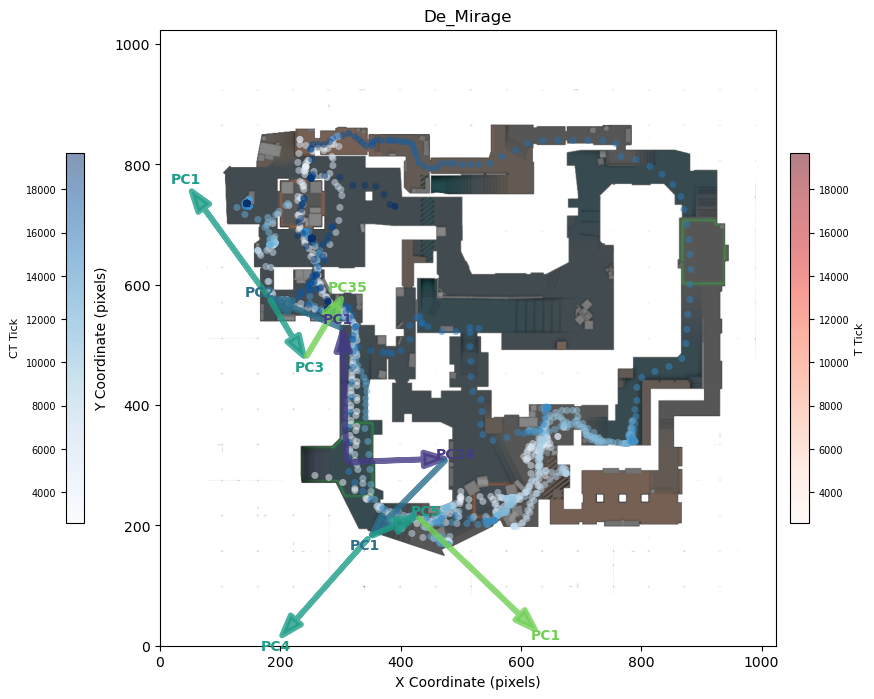

In [51]:
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")
loc_fig, loc_ax = plot_loc_img_unicode(tf_loc[tf_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

for vector in chained_vecs[:]:
    color = plt.get_cmap("viridis")(norm(vector["tick"]))
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color=color,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

    vec_dx = vector["end_pos"][0] -vector["start_pos"][0]
    vec_dy = vector["end_pos"][1] -vector["start_pos"][1]
    
    # Small offset factor from the end of the arrow
    text_offset_factor = 15 
    
    # Adjust offset based on direction of the vector
    # This tries to place text slightly to the "outside" or "ahead" of the arrow
    text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1)
    text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1)

    # If the vector is mostly horizontal, adjust y-offset more. If vertical, adjust x-offset more.
    if abs(vec_dx) > abs(vec_dy): # More horizontal
        text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1) * 0.5 # Less y-offset
    else: # More vertical
        text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1) * 0.5 # Less x-offset


    img_loc_ax.text(vector["end_pos"][0] + text_x_offset,
                    vector['end_pos'][1]+ text_y_offset,
                    f'{vector["name"]}', # Use the 'pc_name' from your vector dictionary
                    color=color, # Use the same color as the arrow
                    fontsize=10, # Adjust font size as needed
                    weight='bold',
                    ha='center', va='center', # Center alignment relative to the text point
                    zorder=11) # Ensure text is above arrows